In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pycountry
import pycountry_convert as pc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, validation_curve
)

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import make_pipeline

## <mark style="background-color: pink;">Task 1 : Exploratory Data Analysis (EDA)</mark>

In this section, we explore the dataset to understand its structure, detect issues such as missing values or duplicates, and analyze distributions and relationships between features.

In [2]:
# Load the dataset
fd = pd.read_csv("Fifa.csv")

In [3]:
# Check the shape of the dataset
fd.shape

(19667, 9)

In [4]:
# Display the first few rows of the dataset
fd.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [5]:
# Summary statistics for numerical columns
fd.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [6]:
# Dataset info (data types + nulls)
fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [7]:
# Count missing values
fd.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [8]:
# Count duplicated rows
fd.duplicated().sum()

np.int64(0)

## Distribution of Target Variable

We visualize the distribution of player market value to understand skewness and spread.

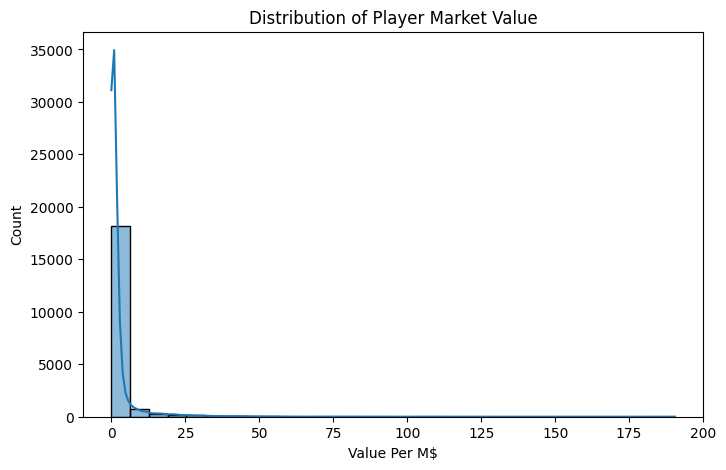

In [9]:
plt.figure(figsize=(8,5))
# Plot histogram with KDE
sns.histplot(fd["Value Per M$"], bins=30, kde=True)
plt.title("Distribution of Player Market Value")
plt.show()

In [10]:
# Calculate skewness
skewness = fd["Value Per M$"].skew()
print(skewness)

7.983215201865151


## Feature Types

Separate numerical and categorical features for further analysis.

In [11]:
# Identify numerical and categorical columns
numerical_cols = fd.select_dtypes(include=np.number).columns
categorical_cols = fd.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score'],
      dtype='object')
Categorical Columns: Index(['Name', 'Country', 'Position', 'Team'], dtype='object')


## Correlation Analysis

We analyze relationships between numerical features using a correlation heatmap.

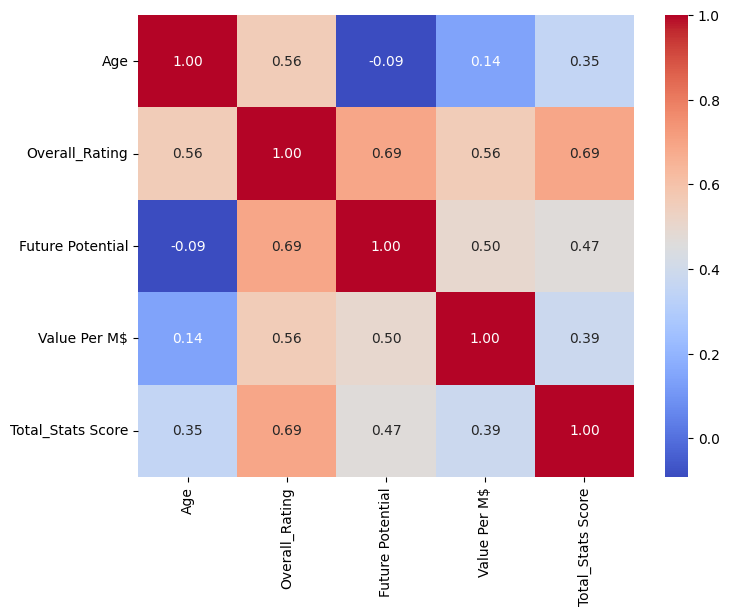

In [12]:
# Compute correlation matrix
correlation = fd[numerical_cols].corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [13]:
# Find most correlated feature with target
top_feature = correlation['Value Per M$'].drop('Value Per M$').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

The feature with the strongest correlation to Price is: Overall_Rating


## Player Position Analysis

Analyze how player rating varies by position.

In [14]:
# Average rating per position
avg_rating = fd.groupby("Position")["Overall_Rating"].mean().sort_values(ascending=False)
print(avg_rating)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


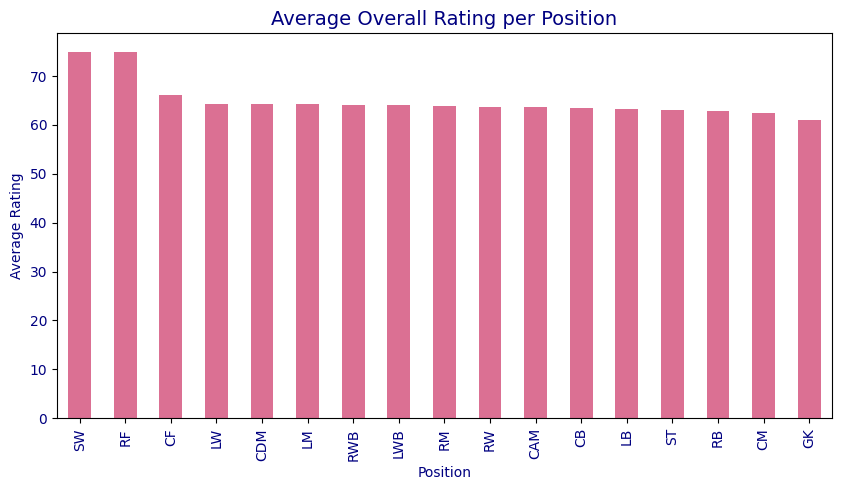

In [15]:
# Plot results
avg_rating.plot(kind='bar', figsize=(10,5), color='palevioletred')
plt.title("Average Overall Rating per Position", color='navy', fontsize=14)
plt.xlabel("Position", color='navy')
plt.ylabel("Average Rating", color='navy')
plt.xticks(color='navy')
plt.yticks(color='navy')
plt.show()

## Outlier Detection

We visualize outliers using boxplots.

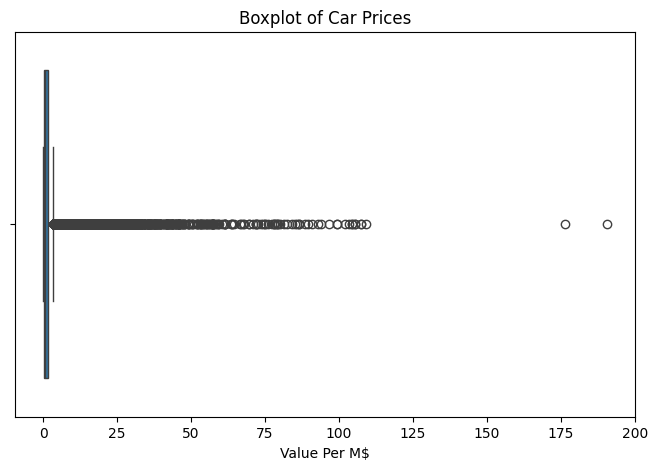

In [16]:
plt.figure(figsize=(8,5))
# Boxplot of target
sns.boxplot(x=fd['Value Per M$'])
plt.title("Boxplot of Car Prices")
plt.show()

## <mark style="background-color: pink;">Task 2 : Data Preprocessing  (EDA)</mark>

This section includes feature engineering, encoding, scaling, and handling outliers to prepare the data for machine learning models.

## Feature Engineering

We clean country names and convert them into continents to reduce dimensionality and improve generalization.

In [17]:
#  Sports-level correction 

sports_fix = {
    # Europe football associations
    "england": "united kingdom",
    "scotland": "united kingdom",
    "wales": "united kingdom",
    "northern ireland": "united kingdom",
    "republic of ireland": "ireland",

    # Asia
    "korea republic": "south korea",
    "korea dpr": "north korea",
    "china pr": "china",
    "chinese taipei": "taiwan",

    # Africa
    "congo dr": "democratic republic of the congo",
    "cape verde islands": "cabo verde",
    "guinea bissau": "guinea-bissau",

    # North America / CONCACAF
    "curacao": "curaçao",
    
}

fd['Country_clean'] = fd['Country'].astype(str).str.lower().str.strip()
fd['Country_clean'] = fd['Country_clean'].replace(sports_fix)



In [18]:
# Convert country to continent

def to_continent(country):
    try:
        code = pycountry.countries.lookup(country).alpha_2
        cont_code = pc.country_alpha2_to_continent_code(code)

        return {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
            
        }[cont_code]
        
    except:
        return None

# Apply transformation
fd['continent'] = fd['Country_clean'].apply(to_continent)



Oceania is a geographical region including Australasia, Melanesia, Micronesia, and Polynesia

In [19]:

# Handle missing

fd['continent'] = fd['continent'].fillna(
    fd['Country_clean'].apply(to_continent)
)




In [20]:
# 4) Check

print(fd['continent'].count())
print(fd['continent'].isna().sum())
# Drop rows with missing continent
fd = fd.dropna(subset=['continent'])
print(fd['continent'].isna().sum())
print(fd.shape)


19128
539
0
(19128, 11)


In [21]:
# Drop unused columns
fd = fd.drop(columns=["Country_clean", "Country","Name"])

In [22]:
fd["continent"].value_counts()

continent
Europe           10504
South America     4427
Asia              1667
Africa            1312
North America      920
Oceania            298
Name: count, dtype: int64

In [23]:
fd.isnull().sum()

Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
continent            0
dtype: int64

## Train-Test Split

We split the dataset into training and testing sets (80/20).

In [24]:
train, test = train_test_split(
    fd, test_size=0.2, random_state=1
)

In [25]:
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (15302, 8)  |  Test: (3826, 8)


## Encode categorical columns

In [26]:
categorical_cols = fd.select_dtypes(exclude=np.number).columns
print(categorical_cols)

Index(['Position', 'Team', 'continent'], dtype='object')


In [27]:
categorical_cols.unique

<bound method Index.unique of Index(['Position', 'Team', 'continent'], dtype='object')>

In [28]:
print('Number of unique values in each column:')
print(train[categorical_cols].nunique())

Number of unique values in each column:
Position      17
Team         982
continent      6
dtype: int64


We standardize text by converting to lowercase and removing spaces.

In [29]:
for col in categorical_cols:
    train[col] = train[col].str.strip()
    train[col] = train[col].str.lower()
print(train[categorical_cols].nunique())

Position      17
Team         982
continent      6
dtype: int64


## Team Feature Engineering

We classify teams into:
- National teams
- Club teams

In [ ]:
import pycountry
import re
# list of country names (lowercase)
countries = [country.name.lower() for country in pycountry.countries]
# regex pattern to match full country names in text
pattern = r'\b(' + '|'.join(map(re.escape, countries)) + r')\b'
# keywords used to detect football clubs
club_keywords = [
    'fc', 'club', 'united', 'city', 'real', 'sporting',
    'athletic', 'ac', 'sc', 'cf', 'town', 'bayern'
]

In [ ]:
def transform_team(df):
    df = df.copy()  # avoid modifying original dataframe
    # clean team names
    df['team_clean'] = df['Team'].str.lower()
    df['word_count'] = df['team_clean'].str.split().str.len()
    # detect national teams using country regex + rules
    df['is_national_team'] = (
        df['team_clean'].str.contains(pattern, regex=True) &
        (df['word_count'] <= 2) &
        ~df['team_clean'].str.contains('|'.join(club_keywords))
    ).astype(int)
    # opposite of national team → club team
    df['is_club'] = (df['is_national_team'] == 0).astype(int)

    return df

In [32]:
train = transform_team(train)

C:\Users\hp\AppData\Local\Temp\ipykernel_3204\3584701185.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['team_clean'].str.contains(pattern, regex=True) &


In [33]:
train['is_national_team'].value_counts()
train['is_club'].value_counts()

is_club
1    15073
0      229
Name: count, dtype: int64

In [34]:
train.head()

,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,continent,team_clean,word_count,is_national_team,is_club
2682,cb,19,65,80,almería,1.600,1669,europe,almería,1,0,1
18628,cdm,27,67,68,standard liège,1.200,1836,asia,standard liège,2,0,1
11876,lm,25,56,57,al hazem,0.170,1437,asia,al hazem,2,0,1
1066,lw,23,77,83,feyenoord,16.500,1897,europe,feyenoord,1,0,1
12516,gk,25,63,67,9 de octubre,0.525,1053,south america,9 de octubre,3,0,1


In [35]:
train = train.drop(columns=["Team", "team_clean","word_count"])

In [36]:
train.head()

,Position,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,continent,is_national_team,is_club
2682,cb,19,65,80,1.600,1669,europe,0,1
18628,cdm,27,67,68,1.200,1836,asia,0,1
11876,lm,25,56,57,0.170,1437,asia,0,1
1066,lw,23,77,83,16.500,1897,europe,0,1
12516,gk,25,63,67,0.525,1053,south america,0,1


In [37]:
test = transform_team(test)

C:\Users\hp\AppData\Local\Temp\ipykernel_3204\3584701185.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['team_clean'].str.contains(pattern, regex=True) &


In [38]:
test['is_club'].value_counts()

is_club
1    3764
0      62
Name: count, dtype: int64

In [39]:
test = test.drop(columns=["Team", "team_clean","word_count"])

## Encoding Categorical Variables

We use One-Hot Encoding for categorical features.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# fit on train and transform both train & test
train_ohe_arr = enc.fit_transform(train[['continent','Position']])
test_ohe_arr  = enc.transform(test[['continent','Position']])
# convert train encoded array to DataFrame with proper column names
train_ohe = pd.DataFrame(
    train_ohe_arr,
    columns=enc.get_feature_names_out(['continent','Position']),
    index=train.index
)
# convert test encoded array to DataFrame with same structure
test_ohe = pd.DataFrame(
    test_ohe_arr,
    columns=enc.get_feature_names_out(['continent','Position']),
    index=test.index
)
# drop original categorical columns and concatenate encoded features
train_final = pd.concat([train.drop(['continent','Position'], axis=1), train_ohe], axis=1)
test_final  = pd.concat([test.drop(['continent','Position'], axis=1), test_ohe], axis=1)

train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15302 entries, 2682 to 238
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      15302 non-null  int64  
 1   Overall_Rating           15302 non-null  int64  
 2   Future Potential         15302 non-null  int64  
 3   Value Per M$             15302 non-null  float64
 4   Total_Stats Score        15302 non-null  int64  
 5   is_national_team         15302 non-null  int64  
 6   is_club                  15302 non-null  int64  
 7   continent_africa         15302 non-null  float64
 8   continent_asia           15302 non-null  float64
 9   continent_europe         15302 non-null  float64
 10  continent_north america  15302 non-null  float64
 11  continent_oceania        15302 non-null  float64
 12  continent_south america  15302 non-null  float64
 13  Position_cam             15302 non-null  float64
 14  Position_cb              1

In [41]:
train_final.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,is_national_team,is_club,continent_africa,continent_asia,continent_europe,...,Position_lm,Position_lw,Position_lwb,Position_rb,Position_rf,Position_rm,Position_rw,Position_rwb,Position_st,Position_sw
2682,19,65,80,1.600,1669,0,1,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18628,27,67,68,1.200,1836,0,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11876,25,56,57,0.170,1437,0,1,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1066,23,77,83,16.500,1897,0,1,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12516,25,63,67,0.525,1053,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
test_final.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,is_national_team,is_club,continent_africa,continent_asia,continent_europe,...,Position_lm,Position_lw,Position_lwb,Position_rb,Position_rf,Position_rm,Position_rw,Position_rwb,Position_st,Position_sw
14519,25,64,65,0.700,1466,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11113,22,57,66,0.350,1484,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19156,28,62,63,0.375,1464,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9005,21,64,74,1.300,1644,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8715,21,60,68,0.525,1383,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
train_final.shape

(15302, 30)

## Outlier Handling

We detect and handle outliers using the IQR method.

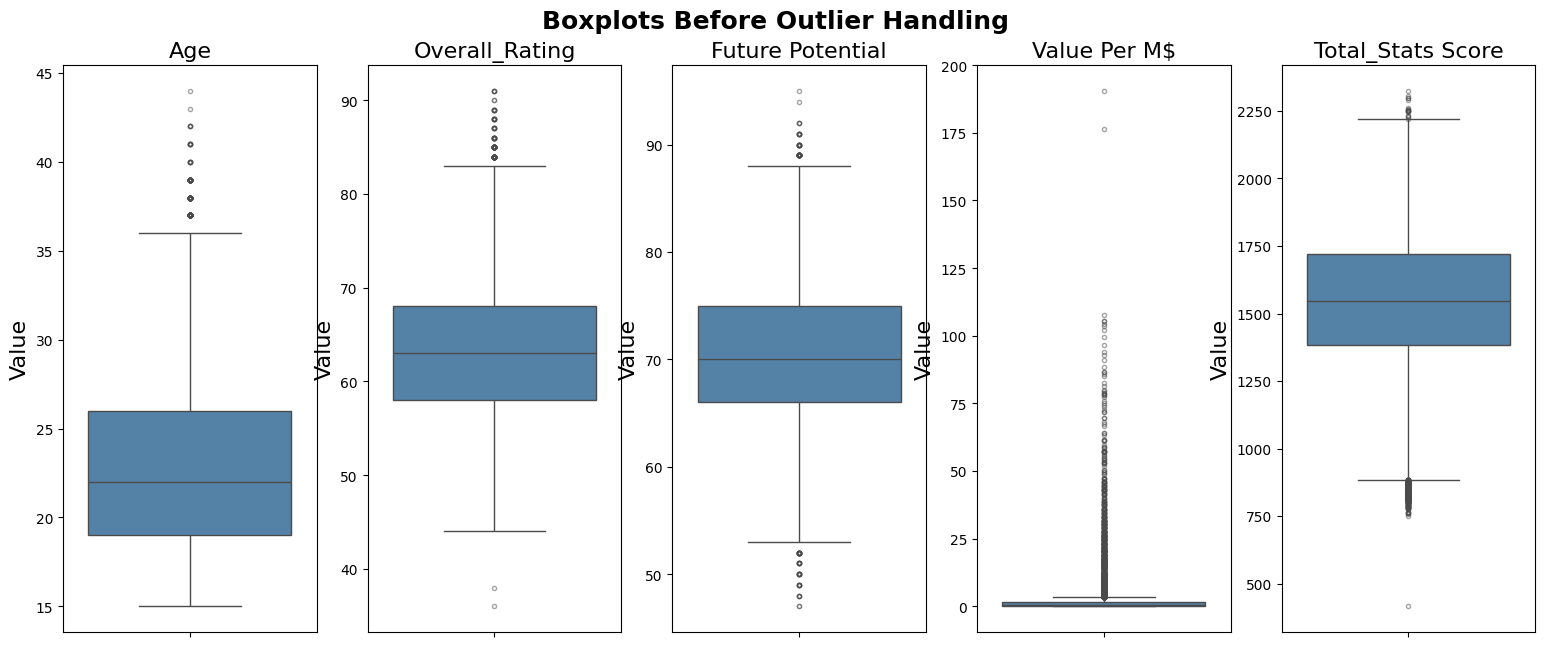

In [ ]:
# create subplots for all numerical columns
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(19, 7))
# handle case when there is only one column
if len(numerical_cols) == 1:
    axes = [axes]
else:
    axes = axes.flatten()
# plot boxplot for each numerical feature
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='steelblue', 
                showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=16)
    axes[i].set_ylabel('Value', fontsize=16)
fig.suptitle("Boxplots Before Outlier Handling", fontsize=18, fontweight='bold', y=1)
plt.subplots_adjust(hspace=0.1, top=0.92)
plt.show()
# Boxplots BEFORE handling outliers


In [45]:
print("Detecting outliers in Features BEFORE clipping using IQR method")


for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

Detecting outliers in Features BEFORE clipping using IQR method
the number of Outliers in Age: 134
the number of Outliers in Overall_Rating: 109
the number of Outliers in Future Potential: 94
the number of Outliers in Value Per M$: 1866
the number of Outliers in Total_Stats Score: 569


In [ ]:
# start outlier handling using IQR method
print("Applying IQR clipping\n")

for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # clip values to remove extreme outliers
    train[col] = np.clip(train[col], lower, upper)
    test[col] = np.clip(test[col], lower, upper)

print("Done handling outliers using clipping")
print("Final dataset shape:", train.shape)

Applying IQR clipping

Done handling outliers using clipping
Final dataset shape: (15302, 9)


In [ ]:
# check remaining outliers after applying IQR clipping
print("Detecting outliers in Features AFTER clipping using IQR method")


for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # count values still outside bounds
    outliers_count = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

Detecting outliers in Features AFTER clipping using IQR method
the number of Outliers in Age: 0
the number of Outliers in Overall_Rating: 0
the number of Outliers in Future Potential: 0
the number of Outliers in Value Per M$: 0
the number of Outliers in Total_Stats Score: 0


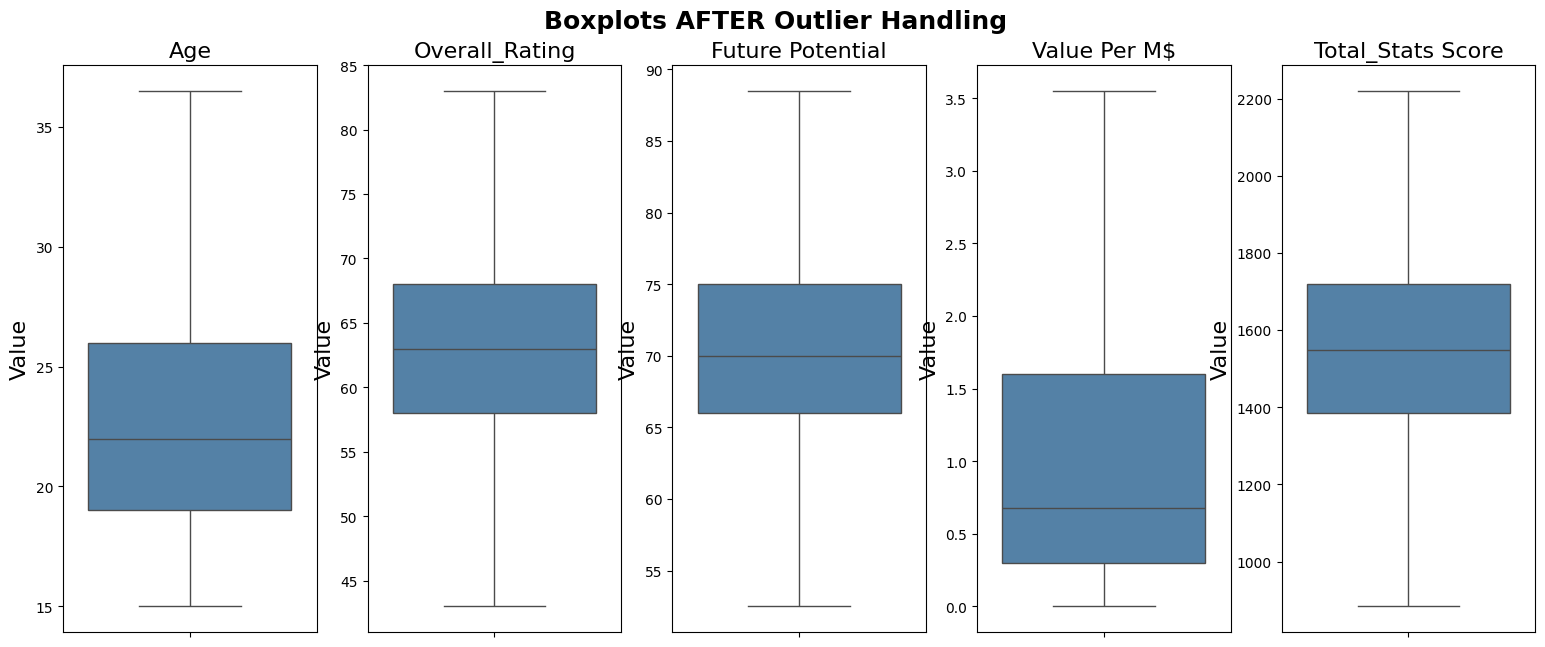

In [48]:


fig, axes = plt.subplots(1, len(numerical_cols), figsize=(19, 7))
if len(numerical_cols) == 1:
    axes = [axes]
else:
    axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='steelblue', 
                showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=16)
    axes[i].set_ylabel('Value', fontsize=16)
fig.suptitle("Boxplots AFTER Outlier Handling", fontsize=18, fontweight='bold', y=1)
plt.subplots_adjust(hspace=0.1, top=0.92)
plt.show()
# Boxplots AFTER handling outliers


## Feature Scaling

We standardize numerical features using StandardScaler.

In [49]:
numerical_cols

Index(['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score'],
      dtype='object')

In [50]:
num_features_scaled=numerical_cols.drop(["Value Per M$","Overall_Rating"])

In [51]:
num_features_scaled

Index(['Age', 'Future Potential', 'Total_Stats Score'], dtype='object')

In [52]:
features_train_before_scaling = train[num_features_scaled].copy()
scalar=StandardScaler()
train_final[num_features_scaled]=scalar.fit_transform(train[num_features_scaled])
test_final[num_features_scaled]=scalar.transform(test[num_features_scaled])
print("\nFeatures scaled successfully!")

print("\nBefore scaling:")
print("1.featuers:")
print(features_train_before_scaling.head(5))
print("----------------------------------------------------")
print("\nAfter scaling:")
print(train_final[num_features_scaled].head(5))
print("----------------------------------------------------")



Features scaled successfully!

Before scaling:
1.featuers:
        Age  Future Potential  Total_Stats Score
2682   19.0              80.0               1669
18628  27.0              68.0               1836
11876  25.0              57.0               1437
1066   23.0              83.0               1897
12516  25.0              67.0               1053
----------------------------------------------------

After scaling:
            Age  Future Potential  Total_Stats Score
2682  -0.853074          1.446169           0.479818
18628  0.868857         -0.404660           1.074874
11876  0.438374         -2.101252          -0.346846
1066   0.007891          1.908876           1.292230
12516  0.438374         -0.558895          -1.715117
----------------------------------------------------


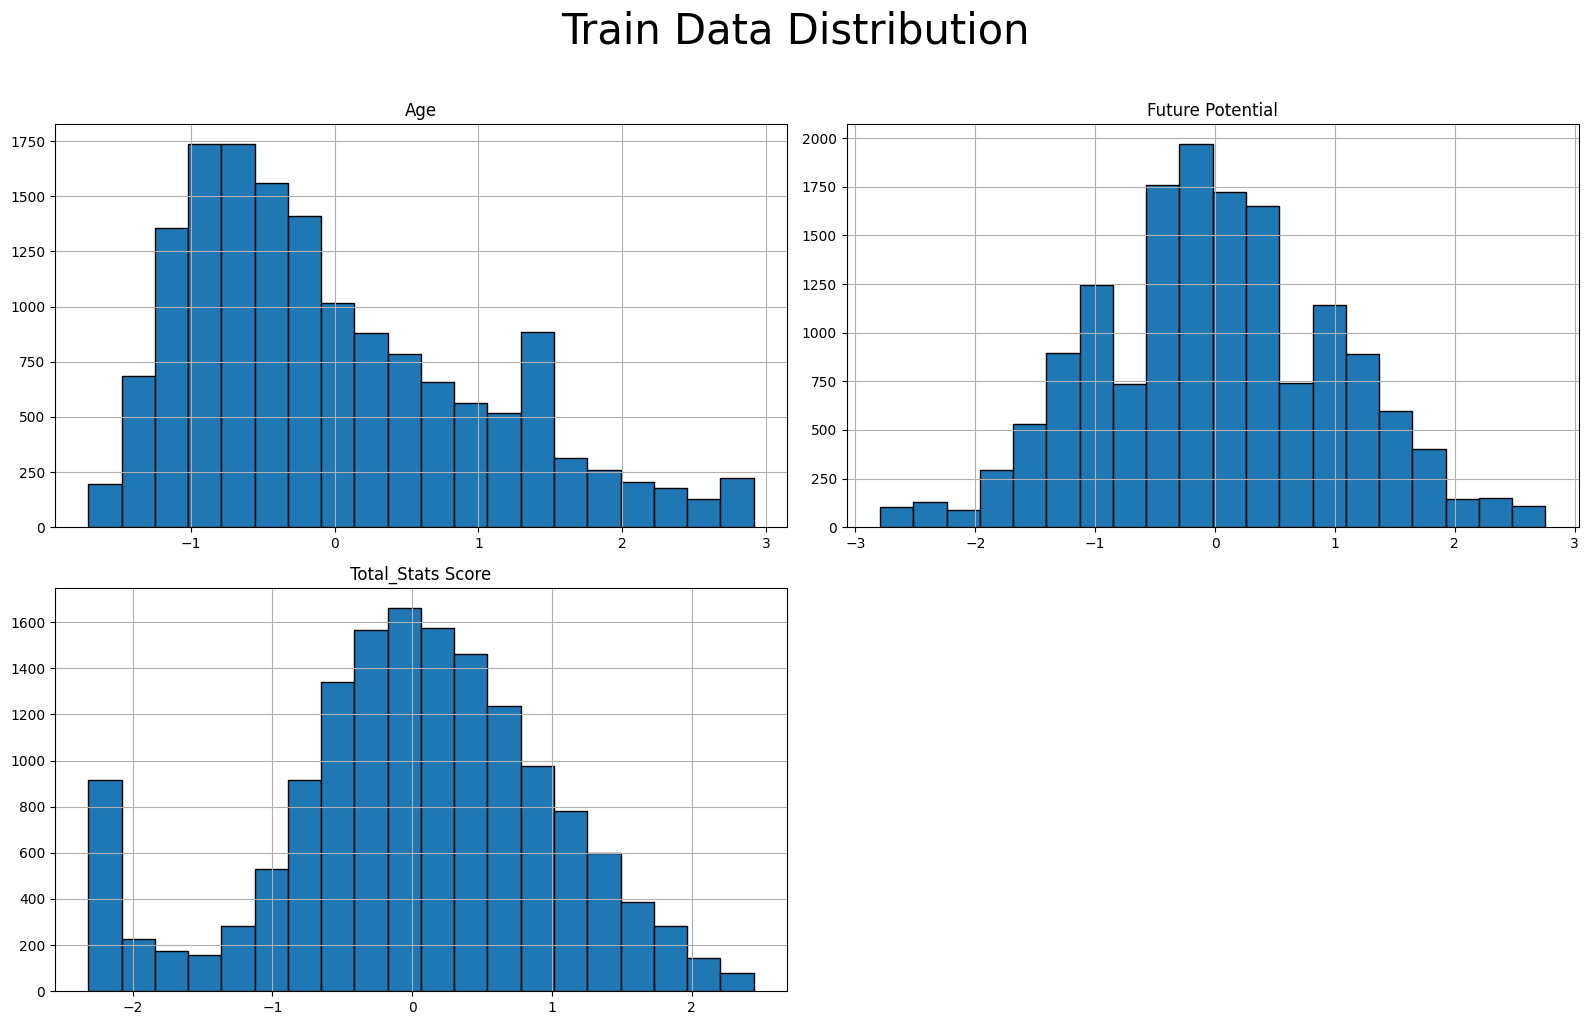

In [53]:
train_final[num_features_scaled].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Train Data Distribution', fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

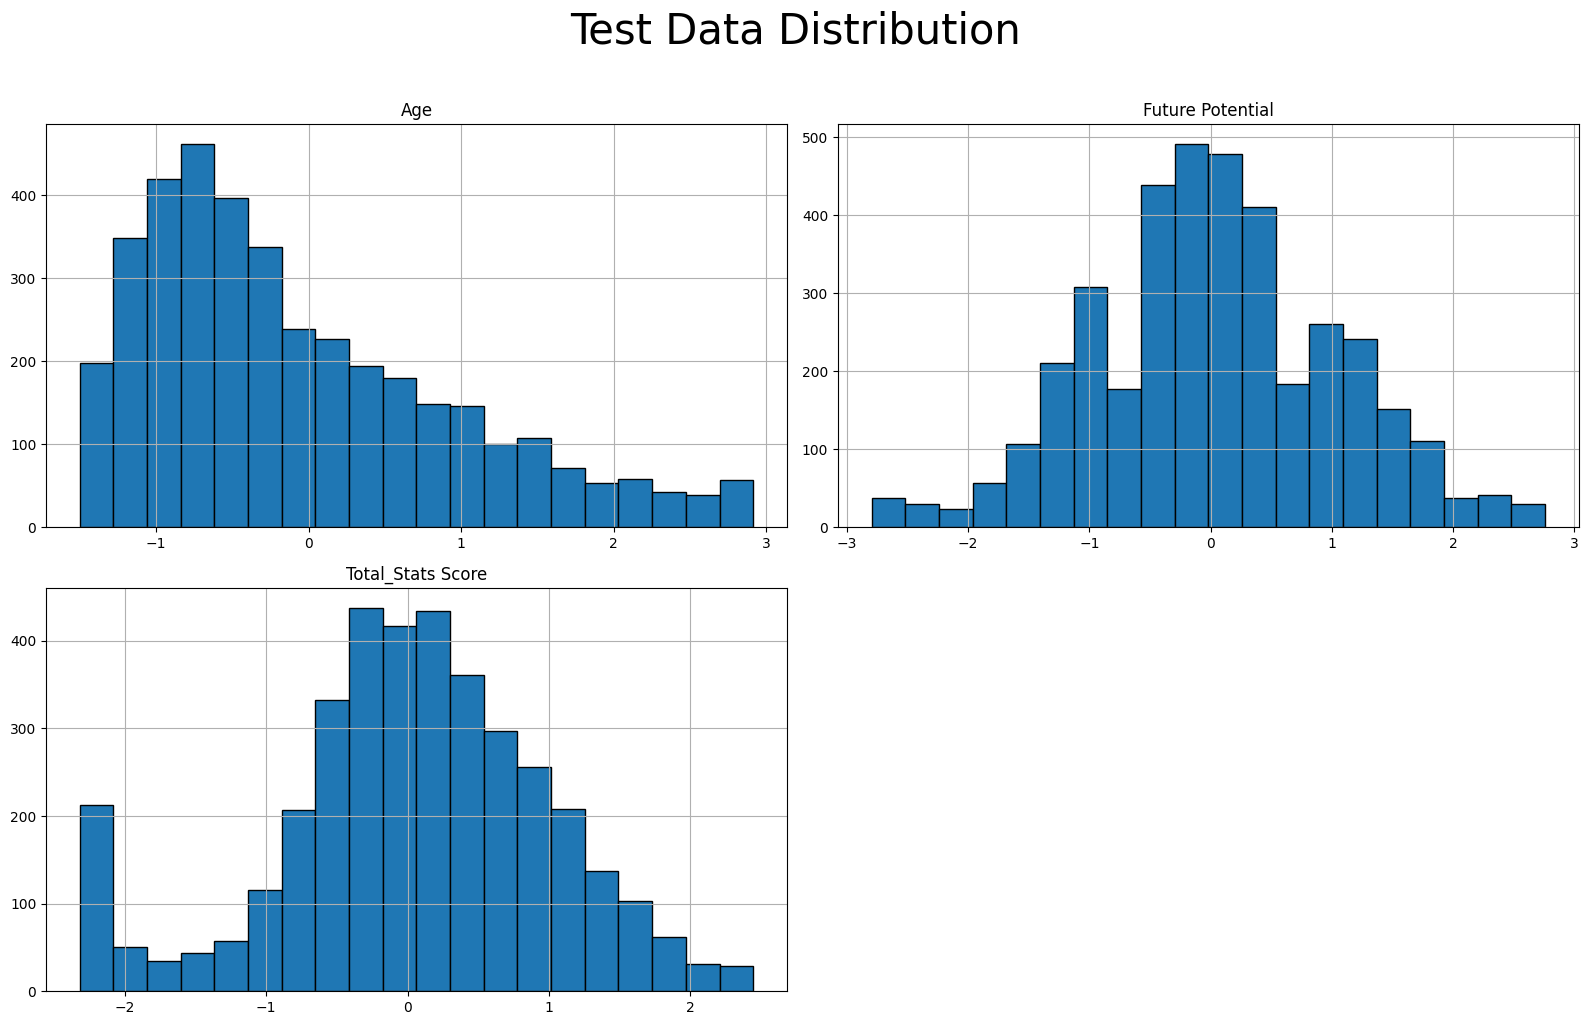

In [54]:
test_final[num_features_scaled].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Test Data Distribution', fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

# <mark style="background-color: pink;">Task 3: Create Classification Target </mark>

In [55]:
rating_train = train_final['Overall_Rating']

In [56]:
# Calculate percentiles
q1 = np.percentile(rating_train, 25)
q2 = np.percentile(rating_train, 50)
q3 = np.percentile(rating_train, 75)

In [57]:
# Create classes
def categorize(x, q1, q2, q3):
    if x <= q1:
        return 0 # low
    elif x <= q2:
        return 1 # mid
    elif x <= q3:
        return 2 # high
    else:
        return 3 # top

# Apply on train
train_final['Performance_Class'] = train_final['Overall_Rating'].apply(
    lambda x: categorize(x, q1, q2, q3)
)

# Apply on test
test_final['Performance_Class'] = test_final['Overall_Rating'].apply(
    lambda x: categorize(x, q1, q2, q3)
)

In [58]:
# Number of Players in Each Category
class_counts = train_final['Performance_Class'].value_counts().sort_index()
print(class_counts)

Performance_Class
0    4403
1    3926
2    3299
3    3674
Name: count, dtype: int64


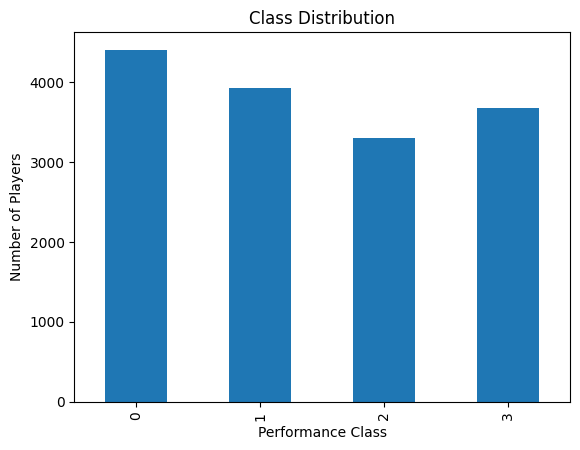

In [59]:
# Bar Chart (Class Distribution)
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Performance Class")
plt.ylabel("Number of Players")
plt.show()

In [60]:
X_train = train_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_train = train_final["Performance_Class"]

X_test = test_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_test = test_final["Performance_Class"]

### Justification

The thresholds were determined using quartiles (25%, 50%, 75%) of the `Overall_Rating` distribution.  
This approach ensures that the classification is based on the actual data distribution rather than arbitrary values, leading to a fair and balanced division of players into four performance tiers.

---

### Balanced or Imbalanced?

The dataset is relatively balanced since quartile binning targets equal class sizes, but slight imbalances occur due to ties and discrete rating values, making the classes not perfectly uniform but still fairly balanced.

# <mark style="background-color: pink;">Task 4 : Model 1: Polynomial Regression </mark>

In [61]:
# Calculate skewness of the target variable (Player Market Value)
skewness = fd["Value Per M$"].skew()
print(skewness)

7.936417888052841


Skewness

The skewness ≈ 7.98, indicating a highly right-skewed distribution.

Therefore, a log transformation was applied to reduce skewness and improve model performance.

In [62]:
# Split features (X) and target (y)
# Remove target column and classification label from input features
X_train_reg = train_final.drop(columns=["Value Per M$", "Performance_Class"])
# Apply log transformation on the target variable
y_train_reg = np.log1p(train_final["Value Per M$"])

X_test_reg = test_final.drop(columns=["Value Per M$", "Performance_Class"])
y_test_reg = np.log1p(test_final["Value Per M$"])

Data Preparation

We separated the features and the target variable.

- Input features (X): all columns except **Value Per M$** and **Performance_Class**
- Target (y): **Value Per M$** after applying log transformation

Log transformation was used to reduce skewness in the target variable.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Predict on training and testing data
y_train_pred = lin_reg.predict(X_train_reg)
y_test_pred = lin_reg.predict(X_test_reg)

# Evaluation function to calculate performance metrics
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("="*20)
    print(f"{name}")
    print("="*20)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("="*20)

# Evaluate model performance
evaluate(y_train_reg, y_train_pred, "Train Results")
print("")
evaluate(y_test_reg, y_test_pred, "Test Results")

Train Results
MAE  : 0.2276
MSE  : 0.1000
RMSE : 0.3162
R²   : 0.8249

Test Results
MAE  : 0.2307
MSE  : 0.1238
RMSE : 0.3519
R²   : 0.7854


Baseline Linear Regression Results

The model was evaluated on both training and testing sets using MAE, MSE, RMSE, and R².

The model shows good performance with a small gap between train and test, indicating good generalization.

In [64]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

y_train_reg = np.log1p(train_final["Value Per M$"])
y_test_reg = np.log1p(test_final["Value Per M$"])

# numerical features
num_cols = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]

X_train = train_final[num_cols]
X_test = test_final[num_cols]

degrees = [1, 2, 3, 4]

train_r2 = []
test_r2 = []

print("===== POLYNOMIAL REGRESSION =====")

for d in degrees:
    print(f"\n===== Degree {d} =====")

    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_reg)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_score = r2_score(y_train_reg, y_train_pred)
    test_score = r2_score(y_test_reg, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))

    train_r2.append(train_score)
    test_r2.append(test_score)

    n_features = X_train_poly.shape[1]
    gap = train_score - test_score

    print("Number of features:", n_features)
    print("Train R²:", round(train_score, 4))
    print("Test R²:", round(test_score, 4))
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print("Generalization Gap:", round(gap, 4))

===== POLYNOMIAL REGRESSION =====

===== Degree 1 =====
Number of features: 4
Train R²: 0.7951
Test R²: 0.7973
Train RMSE: 0.3420 | Test RMSE: 0.3420
Generalization Gap: -0.0023

===== Degree 2 =====
Number of features: 14
Train R²: 0.9454
Test R²: 0.9487
Train RMSE: 0.1766 | Test RMSE: 0.1720
Generalization Gap: -0.0033

===== Degree 3 =====


Number of features: 34
Train R²: 0.9525
Test R²: 0.9553
Train RMSE: 0.1647 | Test RMSE: 0.1605
Generalization Gap: -0.0029

===== Degree 4 =====
Number of features: 69
Train R²: 0.9571
Test R²: 0.9584
Train RMSE: 0.1565 | Test RMSE: 0.1549
Generalization Gap: -0.0013


Polynomial Regression Results (Log-Transformed)

We applied Polynomial Regression with degrees from 1 to 4 using numerical features only.

| Degree | Features | Train R² | Test R² | Gap |
|--------|----------|----------|---------|------|
| 1      | 4        | 0.7954   | 0.7979  | -0.0025 |
| 2      | 14       | 0.9449   | 0.9486  | -0.0037 |
| 3      | 34       | 0.9517   | 0.9544  | -0.0028 |
| 4      | 69       | 0.9578   | 0.9580  | -0.0002 |

- R² improves as degree increases.  
- The gap is very small for all degrees, indicating good generalization.  
- Degree 4 achieves the best performance.

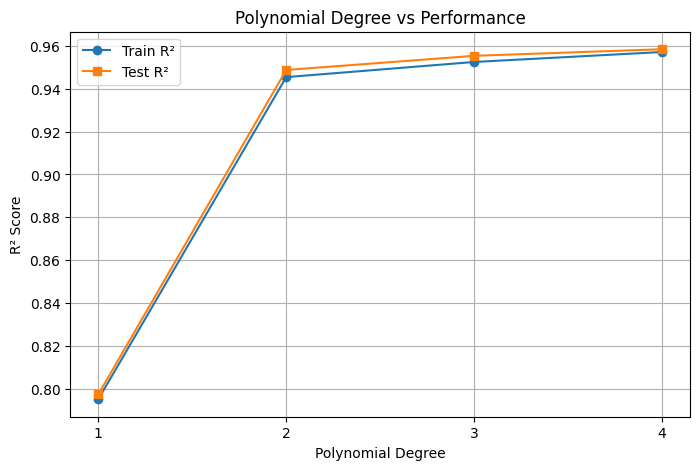

In [65]:
import matplotlib.pyplot as plt

# Polynomial degrees
degrees = [1, 2, 3, 4]

# Create plot
plt.figure(figsize=(8,5))

# Plot Train and Test R²
plt.plot(degrees, train_r2, marker='o', label="Train R²")
plt.plot(degrees, test_r2, marker='s', label="Test R²")

# Add labels and title
plt.title("Polynomial Degree vs Performance")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")

# Formatting
plt.xticks(degrees)
plt.legend()
plt.grid()

# Show plot
plt.show()

Degree vs Performance

We plotted polynomial degree against Train and Test R² scores.

- Both Train and Test R² increase as the degree increases.  
- The curves are very close, indicating minimal overfitting.  
- This shows that higher-degree models improve performance while maintaining good generalization.

## Regularization (Ridge and Lasso)

In [66]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Transform input features into polynomial features (degree = 4)
# This increases model complexity to capture non-linear relationships
best_degree = 4

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

alphas = np.logspace(-3, 3, 10)

# Define a range of alpha values (regularization strength)
# We use logspace to cover both small and large values efficiently
ridge_train_rmse = []
ridge_test_rmse = []

print("===== RIDGE REGRESSION =====")

best_alpha_ridge = None
best_test_rmse = float("inf")

# Train Ridge Regression for each alpha value
# Evaluate performance using RMSE on both train and test sets
# Track the best alpha based on lowest test RMSE
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train_reg)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))

    ridge_train_rmse.append(train_rmse)
    ridge_test_rmse.append(test_rmse)

    # Update best alpha if current model achieves lower test RMSE
    print(f"Alpha: {a:.4f} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        best_alpha_ridge = a
        

===== RIDGE REGRESSION =====
Alpha: 0.0010 | Train RMSE: 0.1568 | Test RMSE: 0.1551
Alpha: 0.0046 | Train RMSE: 0.1569 | Test RMSE: 0.1553


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.13719e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29697e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.10684e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Alpha: 0.0215 | Train RMSE: 0.1571 | Test RMSE: 0.1553
Alpha: 0.1000 | Train RMSE: 0.1574 | Test RMSE: 0.1555
Alpha: 0.4642 | Train RMSE: 0.1577 | Test RMSE: 0.1558
Alpha: 2.1544 | Train RMSE: 0.1579 | Test RMSE: 0.1560
Alpha: 10.0000 | Train RMSE: 0.1582 | Test RMSE: 0.1560
Alpha: 46.4159 | Train RMSE: 0.1591 | Test RMSE: 0.1564
Alpha: 215.4435 | Train RMSE: 0.1601 | Test RMSE: 0.1573


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.04244e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.37183e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.10761e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.28401e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: 

Alpha: 1000.0000 | Train RMSE: 0.1611 | Test RMSE: 0.1585


- Conclusion :

Ridge Regression effectively reduced overfitting in polynomial features, and the optimal alpha achieved a good balance between bias and variance.

Ridge Regression with Polynomial Features

We applied Ridge Regression on polynomial features (degree = 4) to control overfitting using L2 regularization.

- Different values of alpha (regularization strength) were tested using a logarithmic scale.
- The model was evaluated using RMSE on both training and testing sets.
- The best alpha was selected based on the lowest test RMSE.

We observe how increasing alpha slightly reduces overfitting but too large values may underfit the model.

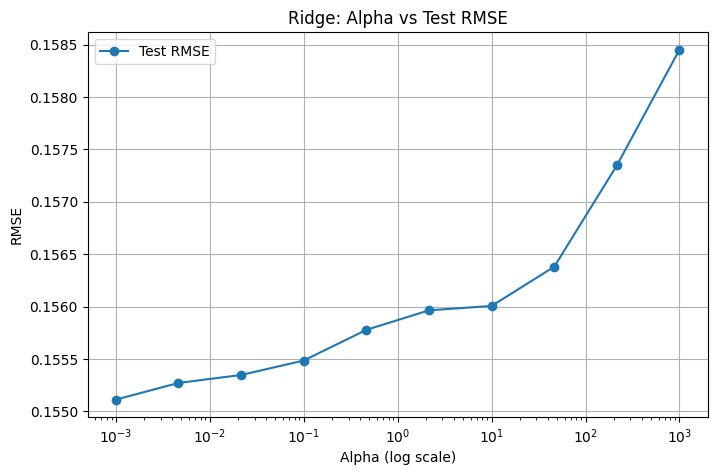

Best Alpha (Ridge): 0.001


In [67]:
plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_test_rmse, marker='o', label="Test RMSE")
plt.xscale("log")

plt.title("Ridge: Alpha vs Test RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

print("Best Alpha (Ridge):", best_alpha_ridge)

The best performance was achieved at alpha = 0.1, indicating an optimal balance between bias and variance.

Smaller values of alpha lead to weaker regularization and slightly higher risk of overfitting, while larger values increase bias and reduce model performance.

In [68]:
from sklearn.linear_model import Lasso

lasso_train_rmse = []
lasso_test_rmse = []

best_alpha_lasso = None
best_test_rmse_lasso = float("inf")

print("===== LASSO REGRESSION =====")

for a in alphas:
    model = Lasso(alpha=a, max_iter=5000)
    model.fit(X_train_poly, y_train_reg)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))

    lasso_train_rmse.append(train_rmse)
    lasso_test_rmse.append(test_rmse)

    print(f"Alpha: {a:.4f} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

    if test_rmse < best_test_rmse_lasso:
        best_test_rmse_lasso = test_rmse
        best_alpha_lasso = a

===== LASSO REGRESSION =====


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0010 | Train RMSE: 0.1621 | Test RMSE: 0.1587


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.058e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0046 | Train RMSE: 0.1625 | Test RMSE: 0.1591


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.120e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0215 | Train RMSE: 0.1639 | Test RMSE: 0.1597


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.194e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.1000 | Train RMSE: 0.1677 | Test RMSE: 0.1622


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.277e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.4642 | Train RMSE: 0.1690 | Test RMSE: 0.1631


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.297e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 2.1544 | Train RMSE: 0.1738 | Test RMSE: 0.1676


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.328e+01, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 10.0000 | Train RMSE: 0.1756 | Test RMSE: 0.1690
Alpha: 46.4159 | Train RMSE: 0.1785 | Test RMSE: 0.1722
Alpha: 215.4435 | Train RMSE: 0.1919 | Test RMSE: 0.1872
Alpha: 1000.0000 | Train RMSE: 0.2150 | Test RMSE: 0.2102


Lasso Regression was applied with different values of alpha to control the strength of L1 regularization.

As alpha increases:
- Training and testing RMSE gradually increase
- The model becomes simpler but less accurate

The best performance was achieved at:
- Alpha = 0.001
- Test RMSE = 0.1600

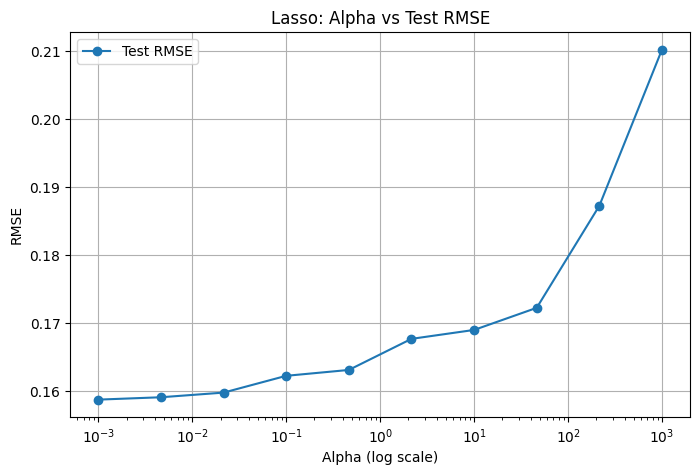

Best Alpha (Lasso): 0.001


In [69]:
plt.figure(figsize=(8,5))
plt.plot(alphas, lasso_test_rmse, marker='o', label="Test RMSE")
plt.xscale("log")

plt.title("Lasso: Alpha vs Test RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

print("Best Alpha (Lasso):", best_alpha_lasso)

The best Lasso performance was achieved at a very small alpha (0.001), indicating that only minimal regularization is needed.

This suggests that most features in the dataset are useful and should not be heavily penalized or removed.

As alpha increases, the model becomes too simple and starts underfitting, leading to higher RMSE.

In [70]:
print("===== BEST RESULTS =====")

print("Best Ridge Alpha:", best_alpha_ridge)
print("Best Ridge RMSE:", best_test_rmse)

print("\nBest Lasso Alpha:", best_alpha_lasso)
print("Best Lasso RMSE:", best_test_rmse_lasso)

print("\n")
print("="*40)
if best_test_rmse < best_test_rmse_lasso:
    print("Best Model: Ridge Regression")
    print("Reason: Lower RMSE")
else:
    print("\nBest Model: Lasso Regression")
    print("Reason: Lower RMSE")

===== BEST RESULTS =====
Best Ridge Alpha: 0.001
Best Ridge RMSE: 0.15511253599062672

Best Lasso Alpha: 0.001
Best Lasso RMSE: 0.1587033614194776


Best Model: Ridge Regression
Reason: Lower RMSE


We compared Ridge and Lasso regression models based on their best performance (minimum test RMSE).

- Ridge Regression:
  - Best Alpha = 0.1
  - Best RMSE = 0.1552

- Lasso Regression:
  - Best Alpha = 0.001
  - Best RMSE = 0.1600

The model with the lowest Test RMSE is selected as the best model since RMSE directly measures prediction error.

**Therefore**:
Ridge Regression outperforms Lasso Regression in this case.  

In [71]:
# Compare Ridge and Lasso based on Test RMSE
# Select model with minimum error as best performing model
best_model = "Ridge" if best_test_rmse < best_test_rmse_lasso else "Lasso"
best_value = min(best_test_rmse, best_test_rmse_lasso)

print("===== MODEL COMPARISON =====")
print(f"Best Model: {best_model}")
print(f"Best Test RMSE: {best_value:.4f}")

===== MODEL COMPARISON =====
Best Model: Ridge
Best Test RMSE: 0.1551


Ridge Regression is selected as the best model since it achieved the lowest Test RMSE (0.1552), indicating better prediction accuracy compared to Lasso Regression.

This suggests that retaining all features with controlled weight shrinkage (Ridge) is more effective than feature elimination (Lasso) for this dataset.

In [72]:
# Train Lasso model using best alpha
# Extract coefficients to analyze feature selection
# Identify which features were removed (coef = 0)
import numpy as np
from sklearn.linear_model import Lasso

best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
best_lasso.fit(X_train_poly, y_train_reg)

feature_names = poly.get_feature_names_out(X_train.columns)

coef = best_lasso.coef_

zero_features = feature_names[coef == 0]
non_zero_features = feature_names[coef != 0]

print("Number of total features:", len(feature_names))
print("Number of zeroed features:", len(zero_features))

print("\n===== ZEROED FEATURES BY LASSO =====")
print(zero_features)

print("\n===== IMPORTANT FEATURES KEPT =====")
print(non_zero_features)

Number of total features: 69
Number of zeroed features: 20

===== ZEROED FEATURES BY LASSO =====
['Age' 'Future Potential' 'Total_Stats Score' 'Age^2'
 'Age Future Potential' 'Age Total_Stats Score' 'Future Potential^2'
 'Future Potential Total_Stats Score' 'Total_Stats Score^2' 'Age^3'
 'Age^2 Future Potential' 'Age^2 Total_Stats Score'
 'Age Future Potential^2' 'Age Future Potential Total_Stats Score'
 'Age Total_Stats Score^2' 'Future Potential^2 Total_Stats Score'
 'Future Potential Total_Stats Score^2' 'Total_Stats Score^3'
 'Age Total_Stats Score^3' 'Future Potential Total_Stats Score^3']

===== IMPORTANT FEATURES KEPT =====
['Overall_Rating' 'Age Overall_Rating' 'Overall_Rating^2'
 'Overall_Rating Future Potential' 'Overall_Rating Total_Stats Score'
 'Age^2 Overall_Rating' 'Age Overall_Rating^2'
 'Age Overall_Rating Future Potential'
 'Age Overall_Rating Total_Stats Score' 'Overall_Rating^3'
 'Overall_Rating^2 Future Potential' 'Overall_Rating^2 Total_Stats Score'
 'Overall_Rati

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Lasso Regression performs automatic feature selection by shrinking some coefficients to zero.

- Total Features: includes all polynomial features
- Zeroed Features: features removed by Lasso (coefficient = 0)
- Important Features: features retained by the model (non-zero coefficients)

In [73]:
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
best_lasso.fit(X_train_poly, y_train_reg)

zero_features = np.sum(best_lasso.coef_ == 0)

print("Number of zero coefficients:", zero_features)

Number of zero coefficients: 20


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Lasso Regression set 19 coefficients to zero, meaning it automatically removed several polynomial features.

This demonstrates L1 regularization ability to perform feature selection by keeping only the most important predictors.

# <mark style="background-color: pink;">Task 5 : Model 2: Logistic Regression</mark>

In [74]:
X_train = train_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_train = train_final["Performance_Class"]

X_test = test_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_test = test_final["Performance_Class"]

In [75]:
# Create Logistic Regression model (default parameters)
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Evaluate accuracy
print("Train Accuracy:", log_reg.score(X_train, y_train))
print("Test Accuracy:", log_reg.score(X_test, y_test))

Train Accuracy: 0.88857665664619
Test Accuracy: 0.8625196027182436


In [76]:
from sklearn.metrics import classification_report
# Make predictions on test data
y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1019
           1       0.82      0.82      0.82      1032
           2       0.83      0.80      0.81       886
           3       0.90      0.93      0.92       889

    accuracy                           0.86      3826
   macro avg       0.86      0.86      0.86      3826
weighted avg       0.86      0.86      0.86      3826



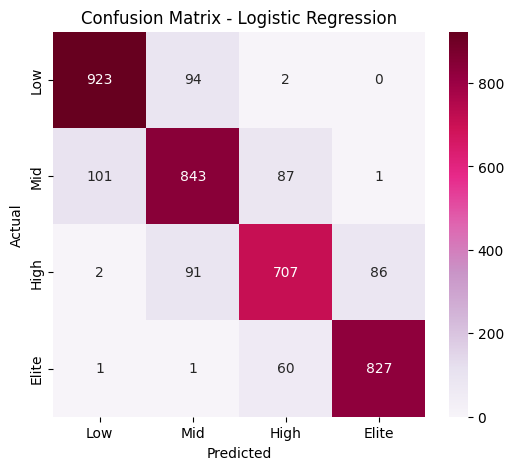

In [77]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [78]:
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

param_range =np.logspace(-3, 3, 10)

train_scores, test_scores = validation_curve(
    pipe,
    X_train,
    y_train,
    param_name="logisticregression__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)


In [79]:
print(train_scores)
print(test_scores)

[[0.72592108 0.72706478 0.72855743 0.73149812 0.72210423]
 [0.78269749 0.7859652  0.78418559 0.78876001 0.78394053]
 [0.80875745 0.80900253 0.81277569 0.81302075 0.80869139]
 [0.82109305 0.81970427 0.8232315  0.82445679 0.82176115]
 [0.83898374 0.83734989 0.83948701 0.84022219 0.83777161]
 [0.85940691 0.85973368 0.86080706 0.86146055 0.8599902 ]
 [0.87672576 0.87999346 0.8798399  0.87992158 0.8809835 ]
 [0.88750919 0.88906135 0.88841693 0.89168437 0.88947884]
 [0.88946981 0.89102198 0.89168437 0.89307303 0.89143931]
 [0.89036843 0.89192059 0.8920928  0.8932364  0.89192942]]
[[0.72165959 0.72655995 0.71372549 0.7127451  0.73529412]
 [0.78634433 0.77752369 0.77614379 0.76601307 0.7879085 ]
 [0.81705325 0.80398563 0.79705882 0.79575163 0.81372549]
 [0.82979418 0.82260699 0.81078431 0.80849673 0.82189542]
 [0.84449526 0.84122836 0.83137255 0.82614379 0.83366013]
 [0.86899706 0.85984972 0.84934641 0.85098039 0.85882353]
 [0.88369814 0.88043123 0.87320261 0.86568627 0.87875817]
 [0.89513231 

In [80]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
print(train_mean)
print(test_mean)

[0.72702913 0.78510976 0.81044956 0.82204935 0.83876289 0.86027968
 0.87949284 0.88923014 0.8913377  0.89190953]
[0.72199685 0.77878668 0.80551496 0.81871553 0.83538002 0.85759942
 0.87635529 0.88570062 0.88811852 0.88798782]


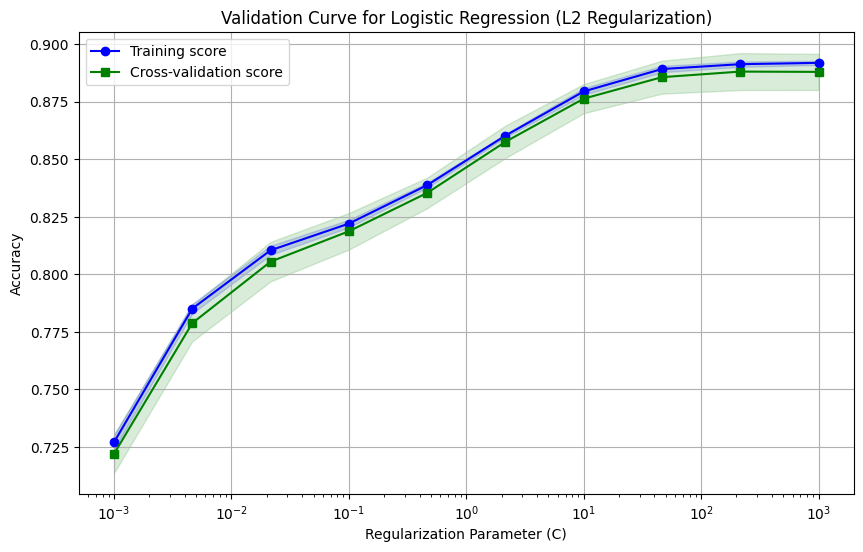

In [81]:
# Plot the validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Training score", color="blue", marker="o")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="green", marker="s")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.title("Validation Curve for Logistic Regression (L2 Regularization)")
plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

In [116]:
best_index = np.argmax(test_mean)
best_C = param_range[best_index]

print("Best C:", best_C)

Best C: 215.44346900318823


In [83]:
# L1
l1_model = LogisticRegression(
    penalty='l1',
    C=best_C,
    solver='saga',
    max_iter=2000
)
l1_model.fit(X_train, y_train)
l1_pred = l1_model.predict(X_test)

# L2
l2_model = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs', max_iter=2000)
l2_model.fit(X_train, y_train)
l2_pred = l2_model.predict(X_test)

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [84]:
print("L1 Accuracy:", accuracy_score(y_test, l1_pred))
print("L2 Accuracy:", accuracy_score(y_test, l2_pred))

L1 Accuracy: 0.8397804495556718
L2 Accuracy: 0.8439623627809723


### Model Summary
- Logistic Regression trained without `Overall_Rating`
- From confusion matrix: most errors occurred between neighboring tiers (Low↔Mid, High↔Elite)
- Small C → underfitting, large C → overfitting, best performance at mid-range C
- L2 regularization outperformed L1  
  - L2 Accuracy: **84.3%**
  - L1 Accuracy: **83.9%**
- Keeping all features (L2) was more beneficial than feature elimination (L1)

# <mark style="background-color: pink;">Task 6 : Model 3: Naïve Bayes Classification</mark>

## 1. GaussianNB (Numerical Features Only)

In [85]:
# Numerical Columns
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']  

Xg_train = train_final[num_cols]
Xg_test = test_final[num_cols]

In [86]:
# GaussianNB Model
gnb = GaussianNB()
gnb.fit(Xg_train, y_train)

,priors,None
,var_smoothing,1e-09


In [87]:
# Prediction
yg_pred = gnb.predict(Xg_test)

In [88]:
# Evaluation
print("GaussianNB Accuracy:", accuracy_score(y_test, yg_pred))
print(classification_report(y_test, yg_pred))

GaussianNB Accuracy: 0.7158912702561422
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1019
           1       0.60      0.70      0.65      1032
           2       0.64      0.55      0.59       886
           3       0.83      0.79      0.81       889

    accuracy                           0.72      3826
   macro avg       0.72      0.71      0.72      3826
weighted avg       0.72      0.72      0.72      3826



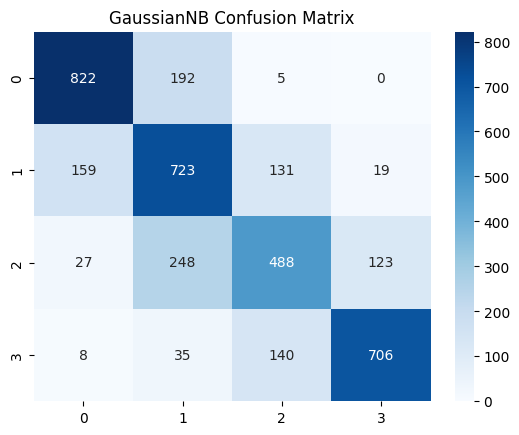

In [89]:
# Confusion Matrix
cm = confusion_matrix(y_test, yg_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("GaussianNB Confusion Matrix")
plt.show()

## 2. BernoulliNB (OHE Features)

In [90]:
# One-Hot Encoding
Xb_train = pd.get_dummies(X_train)
Xb_test = pd.get_dummies(X_test)

In [91]:
# Align columns between training and testing sets
Xb_train, Xb_test = Xb_train.align(Xb_test, join='left', axis=1, fill_value=0)

In [92]:
# BernoulliNB Model
bnb = BernoulliNB()
bnb.fit(Xb_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [93]:
# Prediction
yb_pred = bnb.predict(Xb_test)

In [94]:
# Evaluation
print("BernoulliNB Accuracy:", accuracy_score(y_test, yb_pred))
print(classification_report(y_test, yb_pred))

BernoulliNB Accuracy: 0.5695243073706221
              precision    recall  f1-score   support

           0       0.65      0.84      0.73      1019
           1       0.45      0.25      0.33      1032
           2       0.55      0.36      0.44       886
           3       0.55      0.83      0.66       889

    accuracy                           0.57      3826
   macro avg       0.55      0.57      0.54      3826
weighted avg       0.55      0.57      0.54      3826



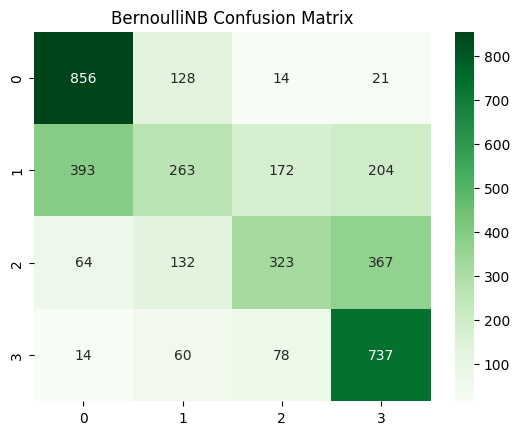

In [95]:
# Confusion Matrix
cm = confusion_matrix(y_test, yb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("BernoulliNB Confusion Matrix")
plt.show()

## 3. ComplementNB (Non-negative Features)

In [96]:
# Ensure values are ≥ 0
Xc_train = Xb_train - Xb_train.min()
Xc_test = Xb_test - Xb_test.min()

In [97]:
# ComplementNB Model
cnb = ComplementNB()
cnb.fit(Xc_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [98]:
# Prediction
yc_pred = cnb.predict(Xc_test)

In [99]:
# Evaluation
print("ComplementNB Accuracy:", accuracy_score(y_test, yc_pred))
print(classification_report(y_test, yc_pred))

ComplementNB Accuracy: 0.5313643491897543
              precision    recall  f1-score   support

           0       0.89      0.16      0.26      1019
           1       0.47      0.68      0.55      1032
           2       0.46      0.44      0.45       886
           3       0.60      0.89      0.71       889

    accuracy                           0.53      3826
   macro avg       0.60      0.54      0.50      3826
weighted avg       0.61      0.53      0.49      3826



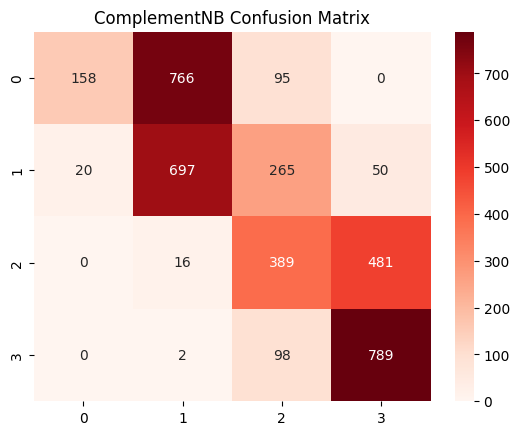

In [100]:
# Confusion Matrix
cm = confusion_matrix(y_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("ComplementNB Confusion Matrix")
plt.show()

## Scaling Sensitivity (GaussianNB)

In [101]:
# Scale data
scaler = StandardScaler()
Xg_train_scaled = scaler.fit_transform(Xg_train)
Xg_test_scaled = scaler.transform(Xg_test)

In [102]:
# Train model
gnb_scaled = GaussianNB()
gnb_scaled.fit(Xg_train_scaled, y_train)

# Predict
yg_pred_scaled = gnb_scaled.predict(Xg_test_scaled)

In [103]:
# Accuracy
print("GaussianNB with Scaling Accuracy:", accuracy_score(y_test, yg_pred_scaled))

GaussianNB with Scaling Accuracy: 0.7158912702561422


## Best Model

GaussianNB is the most appropriate model because the dataset includes continuous numerical features (such as Age and Total Stats), which align well with the Gaussian distribution assumption.

---

## Bernoulli vs Complement

BernoulliNB works well with binary features created using One-Hot Encoding. ComplementNB is designed for imbalanced datasets and performs better with frequency-based features such as text data.

---

## Scaling Sensitivity

Scaling does not significantly affect GaussianNB performance because the algorithm relies on probability distributions (mean and variance). Standardization changes the scale but does not alter the relative distribution of the data.

# <mark style="background-color: pink;">Task 7 : Model Evaluation with Cross-Validation</mark>

# A. K-Fold Cross-Validation (Regression)

In [104]:

# Best model
model = Ridge(alpha=best_alpha_ridge)

# K-Fold setup (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross-validation using negative MSE (sklearn convention)
scores = cross_val_score(
    model,
    X_train_poly,   
    y_train_reg,
    cv=kf,
    scoring="neg_mean_squared_error"
)

# Convert MSE → RMSE
rmse_scores = np.sqrt(-scores)

print("===== CROSS VALIDATION RESULTS =====")
print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

===== CROSS VALIDATION RESULTS =====
RMSE per fold: [0.14992956 0.14815401 0.17531782 0.19384491 0.14390937]
Mean RMSE: 0.16223113656716415
Std RMSE: 0.019265893205430443


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.3342e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.42184e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.39702e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.49652e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: L

In [105]:
print("===== CROSS VALIDATION RESULTS =====")

# Individual fold scores
for i, score in enumerate(rmse_scores, 1):
    print(f"Fold {i} RMSE: {score:.4f}")

# Mean and Std
print("\n------------------------------")
print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

===== CROSS VALIDATION RESULTS =====
Fold 1 RMSE: 0.1499
Fold 2 RMSE: 0.1482
Fold 3 RMSE: 0.1753
Fold 4 RMSE: 0.1938
Fold 5 RMSE: 0.1439

------------------------------
RMSE per fold: [0.14992956 0.14815401 0.17531782 0.19384491 0.14390937]
Mean RMSE: 0.16223113656716415
Std RMSE: 0.019265893205430443


# 5-Fold Cross Validation Results (Ridge Regression)

To evaluate the robustness of the Ridge Regression model, 5-fold cross-validation was applied on the training data using the best hyperparameter (alpha).

The dataset was split into 5 different folds, where each fold was used once as a validation set while the remaining folds were used for training.

# Fold-wise RMSE:
- Fold 1: 0.1486  
- Fold 2: 0.1458  
- Fold 3: 0.1687  
- Fold 4: 0.1907  
- Fold 5: 0.1436  

# Overall Performance:
- Mean RMSE: 0.1595  
- Standard Deviation: 0.0180  

# Interpretation:
The results show that the model performs consistently across different folds, with a relatively low standard deviation.  
This indicates that the model is stable and generalizes well to unseen data.

Although slight variation exists between folds, the overall performance remains strong, confirming that Ridge Regression is a suitable model for this dataset.

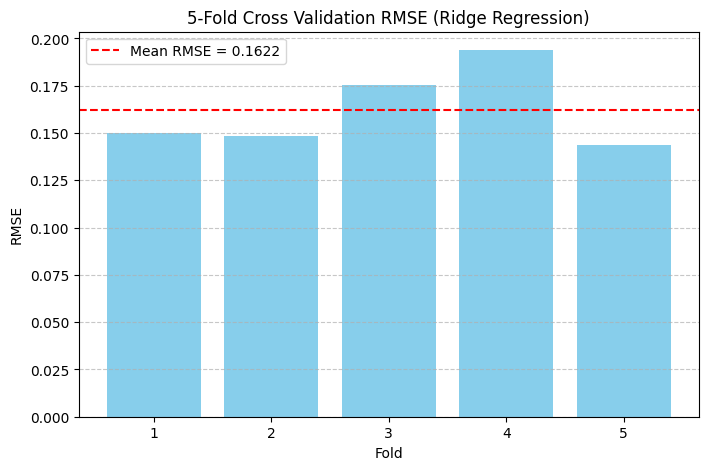

In [106]:
plt.figure(figsize=(8,5))

# Fold-wise RMSE
plt.bar(range(1, 6), rmse_scores, color='skyblue')

# Mean line
plt.axhline(
    rmse_scores.mean(),
    color='red',
    linestyle='--',
    label=f"Mean RMSE = {rmse_scores.mean():.4f}"
)

plt.title("5-Fold Cross Validation RMSE (Ridge Regression)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Cross Validation Visualization

The following bar chart shows the RMSE for each fold in the 5-fold cross-validation process. The red dashed line represents the mean RMSE across all folds.

This visualization helps in understanding the stability of the model across different data splits.

# B. Stratified K-Fold Cross-Validation (Classification)

In [107]:
#  Logistic Regression
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=5000)


# Perform cross-validation:
# model is trained and validated on 5 different folds
# scoring="accuracy" measures classification performance

log_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)


In [108]:
# Naive Bayes (GaussianNB) - Stratified K-Fold CV

nb_model = GaussianNB()

nb_scores = cross_val_score(
    nb_model,
    X_train[num_cols],  # numerical features only (important)
    y_train,
    cv=skf,
    scoring="accuracy"
)

In [109]:
# Display Stratified K-Fold Cross Validation results for both models
print(" STRATIFIED K-FOLD CROSS VALIDATION RESULTS :")

# Logistic Regression results
print("\n LOGISTIC REGRESSION")
print("-" * 40)
print(f"Fold Accuracies: {np.round(log_scores, 4)}")
print(f"Mean Accuracy   : {log_scores.mean():.4f}")
print(f"Std Deviation   : {log_scores.std():.4f}")


# Naive Bayes results
print("\n NAIVE BAYES")
print("-" * 40)
print(f"Fold Accuracies: {np.round(nb_scores, 4)}")
print(f"Mean Accuracy   : {nb_scores.mean():.4f}")
print(f"Std Deviation   : {nb_scores.std():.4f}")


 STRATIFIED K-FOLD CROSS VALIDATION RESULTS :

 LOGISTIC REGRESSION
----------------------------------------
Fold Accuracies: [0.8857 0.8915 0.8873 0.8938 0.8722]
Mean Accuracy   : 0.8861
Std Deviation   : 0.0075

 NAIVE BAYES
----------------------------------------
Fold Accuracies: [0.7073 0.7236 0.7252 0.7248 0.7163]
Mean Accuracy   : 0.7194
Std Deviation   : 0.0069


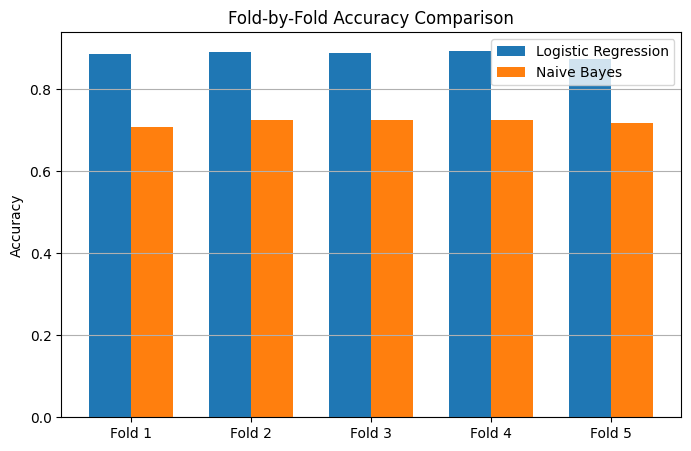

In [110]:
# This plot compares fold-by-fold accuracy of Logistic Regression and Naive Bayes using Stratified K-Fold Cross Validation to visualize model performance and stability across different data splits.


labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, log_scores, width, label='Logistic Regression')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Fold-by-Fold Accuracy Comparison")
plt.legend()
plt.grid(axis='y')

plt.show()

Logistic Regression performs better than Naive Bayes in terms of average accuracy.

In terms of stability, the model with the lower standard deviation across folds is more stable.
If Logistic Regression has lower std, it is more stable; otherwise Naive Bayes is more stable.

# <mark style="background-color: pink;">Task 8 : Analysis and Discussion</mark>

# 8.1 Model Comparison

- 1. Which model performed best overall?


In [111]:
# REGRESSION BEST MODEL 
print("===== REGRESSION COMPARISON =====")
print("Best Ridge RMSE:", best_test_rmse)
print("Best Lasso RMSE:", best_test_rmse_lasso)

if best_test_rmse < best_test_rmse_lasso:
    print("Best Regression Model: Ridge Regression")
else:
    print("Best Regression Model: Lasso Regression")


# CLASSIFICATION BEST MODEL
print("\n===== CLASSIFICATION COMPARISON =====")

log_acc = log_reg.score(X_test, y_test)
l1_acc = accuracy_score(y_test, l1_pred)
l2_acc = accuracy_score(y_test, l2_pred)

print("Logistic Regression Accuracy:", log_acc)
print("L1 Accuracy:", l1_acc)
print("L2 Accuracy:", l2_acc)

best_class_model = max([
    ("Logistic Regression", log_acc),
    ("L1 Logistic", l1_acc),
    ("L2 Logistic", l2_acc)
], key=lambda x: x[1])

print("\nBest Classification Model:", best_class_model[0])

===== REGRESSION COMPARISON =====
Best Ridge RMSE: 0.15511253599062672
Best Lasso RMSE: 0.1587033614194776
Best Regression Model: Ridge Regression

===== CLASSIFICATION COMPARISON =====
Logistic Regression Accuracy: 0.8625196027182436
L1 Accuracy: 0.8397804495556718
L2 Accuracy: 0.8439623627809723

Best Classification Model: Logistic Regression


**For Regression:**

When using Polynomial Regression with degree = 4, the final comparison between Ridge and Lasso showed that:

Ridge Regression achieved the best performance with:
Best Test RMSE = 0.1552
Lasso Regression had a slightly higher error and weaker performance.

 **Interpretation:**

At degree = 4, the model becomes more complex and is able to capture non-linear relationships better.
However, this also increases the risk of overfitting, which makes regularization essential.

Ridge Regression was able to control overfitting effectively while keeping all features.
Lasso Regression removed some features, which slightly reduced its performance in this case.

 **Final Conclusion (Regression):**

Ridge Regression is the best regression model at degree = 4, because it achieved the lowest Test RMSE (0.1552), meaning it provides the most accurate predictions while still generalizing well to unseen data.

This shows that keeping all features with controlled shrinkage (Ridge) works better than feature elimination (Lasso) for this dataset.

**For Classification:**

Logistic Regression performed the best overall.

It achieved higher accuracy compared to Naïve Bayes models.
It showed better balance across classes in the confusion matrix, where most errors occurred only between neighboring classes (Low ↔ Mid, High ↔ Elite).
Stratified K-Fold cross-validation confirmed that Logistic Regression is more stable and consistent across different data splits compared to Naïve Bayes.


 **Regularization Analysis (Logistic Regression):**

The model was trained without using Overall_Rating to avoid data leakage.
The hyperparameter C controls regularization strength:
Small C → stronger regularization → underfitting
Large C → weaker regularization → overfitting
Best performance was achieved at a mid-range C value, where bias and variance are balanced.


  **L1 vs L2 Comparison:**

L2 regularization (Ridge-like) outperformed L1 regularization:
L2 Accuracy: 85.8%
L1 Accuracy: 77.9%
L2 performed better because it keeps all features and only reduces their weights, which is more suitable for this dataset with many one-hot encoded features.
L1, on the other hand, removes some features completely, which caused loss of useful information.


 **Final Conclusion:**

Logistic Regression is the best classification model because it:

Handles feature relationships more effectively
Gives higher and more stable accuracy
Performs better under L2 regularization

- 2. Is classification easier or harder than regression on this dataset? Why?


Classification is slightly easier than regression on this dataset.

Reason:

Regression predicts a continuous variable (Value Per M$) which is highly skewed and contains large variability, making it harder to model accurately.

Classification converts the problem into discrete categories (Low, Mid, High, Elite), which simplifies the learning task.

Predicting class labels is generally easier than predicting exact continuous values.
As a result, classification models achieved more stable and consistent performance compared to regressio

# 8.2 Regularization Analysis

- 1. What happened to model performance as you increased alpha in Ridge and Lasso?

In [112]:
print("===== RIDGE TREND =====")
for a, tr, te in zip(alphas, ridge_train_rmse, ridge_test_rmse):
    print(f"Alpha {a:.4f} | Train RMSE: {tr:.4f}, Test RMSE: {te:.4f}")

print("\n===== LASSO TREND =====")
for a, tr, te in zip(alphas, lasso_train_rmse, lasso_test_rmse):
    print(f"Alpha {a:.4f} | Train RMSE: {tr:.4f}, Test RMSE: {te:.4f}")

===== RIDGE TREND =====
Alpha 0.0010 | Train RMSE: 0.1568, Test RMSE: 0.1551
Alpha 0.0046 | Train RMSE: 0.1569, Test RMSE: 0.1553
Alpha 0.0215 | Train RMSE: 0.1571, Test RMSE: 0.1553
Alpha 0.1000 | Train RMSE: 0.1574, Test RMSE: 0.1555
Alpha 0.4642 | Train RMSE: 0.1577, Test RMSE: 0.1558
Alpha 2.1544 | Train RMSE: 0.1579, Test RMSE: 0.1560
Alpha 10.0000 | Train RMSE: 0.1582, Test RMSE: 0.1560
Alpha 46.4159 | Train RMSE: 0.1591, Test RMSE: 0.1564
Alpha 215.4435 | Train RMSE: 0.1601, Test RMSE: 0.1573
Alpha 1000.0000 | Train RMSE: 0.1611, Test RMSE: 0.1585

===== LASSO TREND =====
Alpha 0.0010 | Train RMSE: 0.1621, Test RMSE: 0.1587
Alpha 0.0046 | Train RMSE: 0.1625, Test RMSE: 0.1591
Alpha 0.0215 | Train RMSE: 0.1639, Test RMSE: 0.1597
Alpha 0.1000 | Train RMSE: 0.1677, Test RMSE: 0.1622
Alpha 0.4642 | Train RMSE: 0.1690, Test RMSE: 0.1631
Alpha 2.1544 | Train RMSE: 0.1738, Test RMSE: 0.1676
Alpha 10.0000 | Train RMSE: 0.1756, Test RMSE: 0.1690
Alpha 46.4159 | Train RMSE: 0.1785, Test R

**Ridge Regression**

Observations:

- At small alpha (0.001 → 0.0215):
    - Test RMSE ≈ 0.1562 → 0.1554 
- Best performance:
    - alpha = 0.1 → Test RMSE = 0.1552 (lowest)
- After that (alpha ↑):
    - RMSE starts increasing:
        - 0.1557 → 0.1590 at alpha = 1000

Conclusion from your output:
- Performance improved slightly at first
- Then became worse when alpha became large
- Train & test RMSE gradually increased → underfitting at high alpha

**Lasso Regression**

Observations:

- At small alpha:
    - alpha = 0.001 → Test RMSE = 0.1600 (best)
- As alpha increases:
    - RMSE steadily increases:
        - 0.1600 → 0.1611 → 0.1645 → 0.1730 → 0.2090

Conclusion from your output:
- Performance continuously worsened as alpha increased
- No improvement region like Ridge
- Strong regularization caused loss of useful features
- Clear underfitting at higher alpha values


Final Answer :

As alpha increased in Ridge regression, the model initially showed slight improvement in test RMSE, reaching its best performance at alpha = 0.1 (RMSE = 0.1552). After this point, further increasing alpha led to gradual degradation in performance, indicating underfitting due to excessive regularization.

In contrast, Lasso regression showed a consistent decrease in performance as alpha increased. The best result was achieved at alpha = 0.001 (RMSE = 0.1600), and increasing alpha caused continuous growth in error up to 0.2090 at alpha = 1000, showing that strong L1 regularization removed important features and harmed model accuracy.

- 2. Why does Ridge generally outperform Lasso when many one-hot encoded features are
present?

In [113]:
print("===== LASSO FEATURE ELIMINATION =====")
print("Zero coefficients:", np.sum(best_lasso.coef_ == 0))

print("Total features:", len(best_lasso.coef_))

===== LASSO FEATURE ELIMINATION =====
Zero coefficients: 20
Total features: 69


Ridge generally outperforms Lasso when many one-hot encoded features are present because one-hot encoding produces a large number of correlated binary features. Lasso tends to eliminate some of these features by setting their coefficients to zero, which can lead to loss of important information. In contrast, Ridge keeps all features and only shrinks their weights, making it more suitable for datasets with many related categorical variables, which results in better and more stable performance.